# Semiconductor Quality Control - Final Notebook
---
Sequential analysis of semiconductor defects using Logistic Regression, including regularization and threshold tuning.


# 1. Imports and Setup


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, fbeta_score, recall_score, precision_score, accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import matthews_corrcoef
from sklearn.pipeline import Pipeline

# Imports for SVM
from sklearn.svm import SVC

# Imports for Adaboost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 35
FOLDS = 4
FILE_PATH = 'semiconductor_quality_control.csv'


# 2. Preliminaries
## 2.1 Load Data and Cleaning


In [3]:
print(f">>> Loading Data from {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
sybau = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Defect', 'Join_Status']
x = df.drop(columns=sybau)
y = df['Defect']
x = pd.get_dummies(x, columns=['Tool_Type'], drop_first=True)
print("Data loaded. Shape:", x.shape)
df.info()

>>> Loading Data from semiconductor_quality_control.csv...
Data loaded. Shape: (4219, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4219 entries, 0 to 4218
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Process_ID             4219 non-null   object 
 1   Timestamp              4219 non-null   object 
 2   Tool_Type              4219 non-null   object 
 3   Wafer_ID               4219 non-null   object 
 4   Chamber_Temperature    4219 non-null   float64
 5   Gas_Flow_Rate          4219 non-null   float64
 6   RF_Power               4219 non-null   float64
 7   Etch_Depth             4219 non-null   float64
 8   Rotation_Speed         4219 non-null   float64
 9   Vacuum_Pressure        4219 non-null   float64
 10  Stage_Alignment_Error  4219 non-null   float64
 11  Vibration_Level        4219 non-null   float64
 12  UV_Exposure_Intensity  4219 non-null   float64
 13  Particle_Count    

## 2.2 Train/Test Split and Normalization


In [4]:
numerical_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth',
                  'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error',
                  'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
scaler.fit(x_train[numerical_cols])
x_train = x_train.copy()
x_test = x_test.copy()
x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

print('Pre-processing done!')


Pre-processing done!


# 3. Exploratory Data Analysis
## 3.1 Feature Importance via L1 Regression

We use L1 (Lasso) regularization to identify the most important features. L1 regularization penalizes the sum of absolute coefficient values, which tends to shrink unimportant feature coefficients to exactly zero. This makes it useful for feature selection. The stem plot below shows the absolute magnitude of each coefficient after fitting an L1-regularized model.


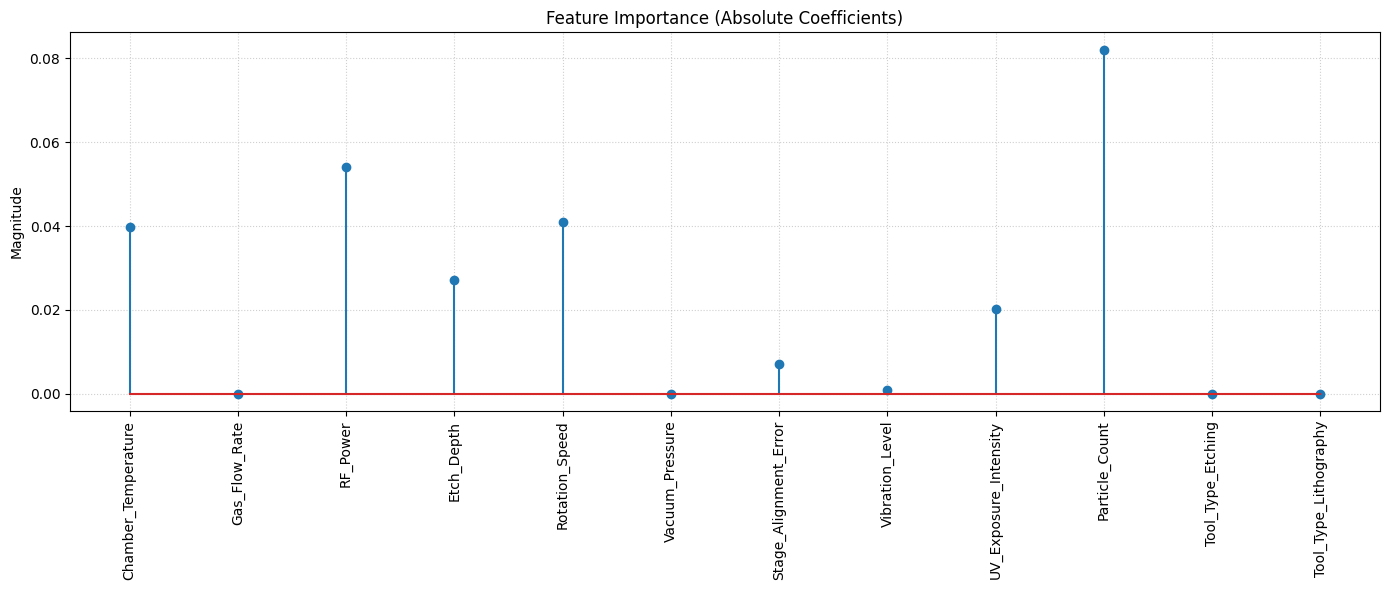

Top 5 Most Important Features -
Particle_Count = -0.0821168137300928
RF_Power = -0.054168100390850474
Rotation_Speed = -0.040942439301575206
Chamber_Temperature = 0.03967967596135008
Etch_Depth = 0.027171211160181483


In [5]:
model_eda = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', class_weight='balanced', random_state=1)
model_eda.fit(x_train, y_train)
theta_star = model_eda.coef_[0]
feature_names = x.columns

plt.figure(figsize=(14, 6))
plt.stem(np.abs(theta_star))
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=10)
plt.title('Feature Importance (Absolute Coefficients)')
plt.ylabel('Magnitude')
plt.grid(linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features -")
top_indices = np.argsort(np.abs(theta_star))[::-1][:5]
for i in top_indices:
    print(feature_names[i], "=", theta_star[i])


# 4. Baseline Modeling
## 4.1 Vanilla Logistic Regression


In [6]:
model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
model.fit(x_train, y_train)
print('Vanilla Model Trained!')


Vanilla Model Trained!


## 4.2 Cross Validation Evaluation


In [7]:
pipeline = Pipeline([('scaler', StandardScaler()),('classifier', LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE))])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
f2_scorer = make_scorer(fbeta_score, beta=2)
scoring = {'recall': 'recall','precision': 'precision','f1': 'f1','accuracy': 'accuracy','f2': f2_scorer}
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"Fold  Recall  F2 Score  Precision  F1  Accuracy ")
print("-" * 65)
for i in range(4):
    print(f"{i+1} {scores['test_recall'][i]} {scores['test_f2'][i]} {scores['test_precision'][i]} {scores['test_f1'][i]} {scores['test_accuracy'][i]}")
print("-" * 65)
print("Mean Recall:", np.mean(scores['test_recall']))
print("Mean F2:", np.mean(scores['test_f2']))


Fold  Recall  F2 Score  Precision  F1  Accuracy 
-----------------------------------------------------------------
1 0.4805194805194805 0.3327338129496403 0.14919354838709678 0.2276923076923077 0.524170616113744
2 0.44155844155844154 0.3082502266545784 0.13963039014373715 0.2121684867394696 0.5213270142180095
3 0.432258064516129 0.30344202898550726 0.1384297520661157 0.20970266040688576 0.5213270142180095
4 0.487012987012987 0.3345227475468332 0.1485148514851485 0.2276176024279211 0.5170777988614801
-----------------------------------------------------------------
Mean Recall: 0.4603372434017595
Mean F2: 0.31973720403413974


# 5. Regularization Analysis
## 5.1 Grid Search over L1/L2 and C values


In [39]:
penalties = ['l1', 'l2']
C_values = np.logspace(-5, 5, 10)
results = []

print(f"Penalty  C  F2  Recall ")
print("-" * 50)

for penalty in penalties:
    for C in C_values:
        solver = 'liblinear'
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty=penalty,
                C=C,
                solver=solver,
                class_weight='balanced',
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])

        cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=RANDOM_STATE)
        f2_scores = cross_val_score(pipeline, x, y, cv=cv, scoring=f2_scorer)
        rec_scores = cross_val_score(pipeline, x, y, cv=cv, scoring='recall')

        mean_f2 = np.mean(f2_scores)
        mean_rec = np.mean(rec_scores)

        results.append({'Penalty': penalty, 'C': C, 'F2': mean_f2, 'Recall': mean_rec})
        print(f"{penalty} {C:.5f} {mean_f2:.4f} {mean_rec:.4f}")

results_df = pd.DataFrame(results)


Penalty  C  F2  Recall 
--------------------------------------------------
l1 0.00001 0.0000 0.0000
l1 0.00013 0.0000 0.0000
l1 0.00167 0.0000 0.0000
l1 0.02154 0.3366 0.4959
l1 0.27826 0.3286 0.4782
l1 3.59381 0.3185 0.4587
l1 46.41589 0.3197 0.4603
l1 599.48425 0.3197 0.4603
l1 7742.63683 0.3197 0.4603
l1 100000.00000 0.3197 0.4603
l2 0.00001 0.3316 0.4863
l2 0.00013 0.3299 0.4830
l2 0.00167 0.3308 0.4814
l2 0.02154 0.3204 0.4620
l2 0.27826 0.3198 0.4603
l2 3.59381 0.3197 0.4603
l2 46.41589 0.3197 0.4603
l2 599.48425 0.3197 0.4603
l2 7742.63683 0.3197 0.4603
l2 100000.00000 0.3197 0.4603


## 5.2 Regularization Impact


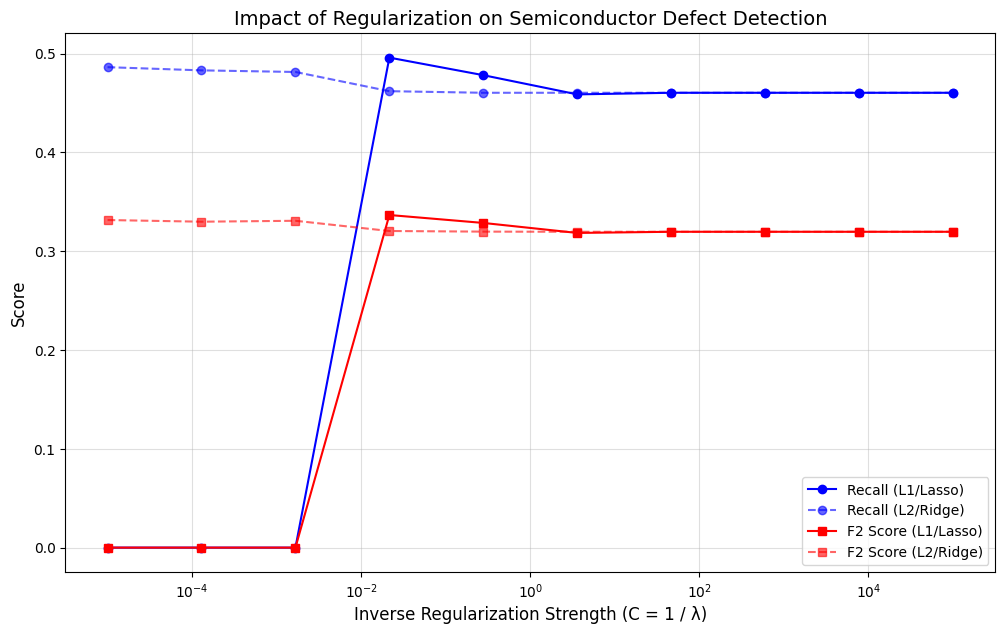

In [9]:
plt.figure(figsize=(12, 7))

df_l1 = results_df[results_df['Penalty'] == 'l1']
df_l2 = results_df[results_df['Penalty'] == 'l2']

plt.plot(df_l1['C'], df_l1['Recall'], label='Recall (L1/Lasso)', color='blue', marker='o', linestyle='-')
plt.plot(df_l2['C'], df_l2['Recall'], label='Recall (L2/Ridge)', color='blue', marker='o', linestyle='--', alpha=0.6)
plt.plot(df_l1['C'], df_l1['F2'], label='F2 Score (L1/Lasso)', color='red', marker='s', linestyle='-')
plt.plot(df_l2['C'], df_l2['F2'], label='F2 Score (L2/Ridge)', color='red', marker='s', linestyle='--', alpha=0.6)

plt.xscale('log')
plt.xlabel('Inverse Regularization Strength (C = 1 / λ)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Impact of Regularization on Semiconductor Defect Detection', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.show()


We can compare in the above plot, L1 (Lasso) and L2 (Ridge) regularizations across different values of C (Inverse of regularization strengths, so lower C means stronger regularization). 

## 5.3 Regularization Path (L1)


------------------------------
Best F2 Score: 0.3443
Best Penalty:  l1
Best C:        0.02807
------------------------------


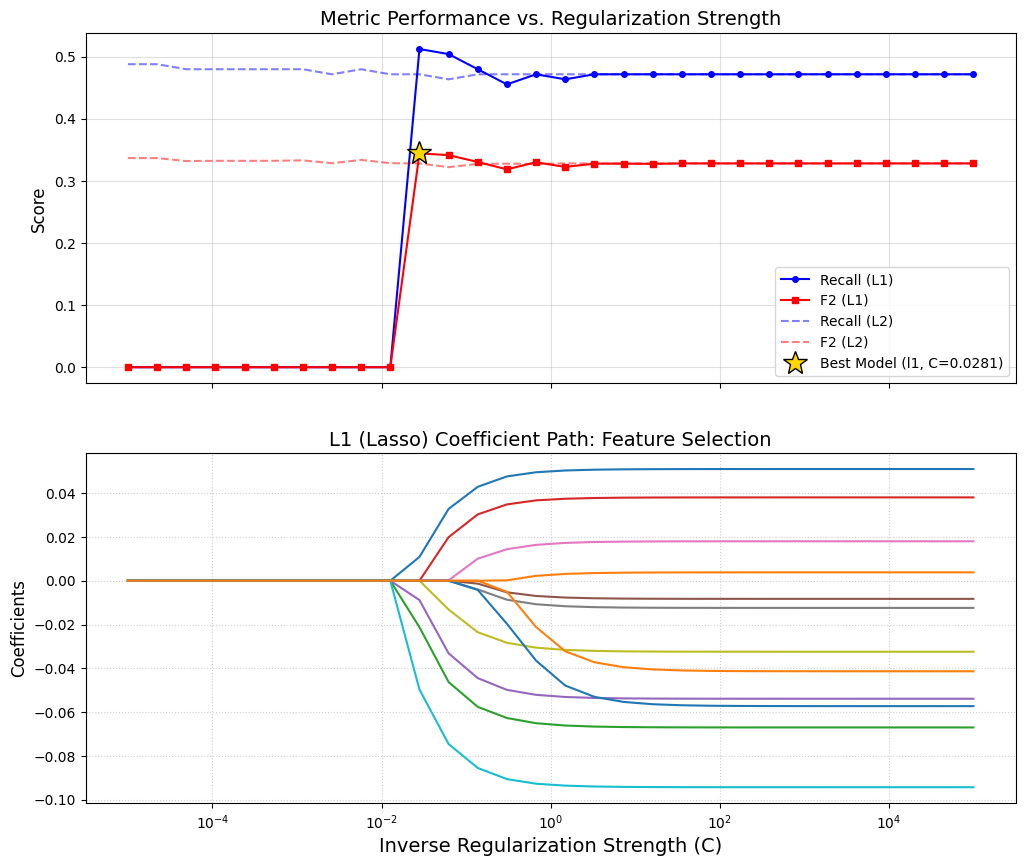

In [41]:
Cs = np.logspace(-5, 5, 30)
penalties = ['l1', 'l2']
results_list = []
coefs_l1 = [] 

best_f2 = -1
best_params = {}

for penalty in penalties:
    for C in Cs:
        model = LogisticRegression(
            penalty=penalty, 
            C=C, 
            solver='liblinear', 
            class_weight='balanced', 
            random_state=42
        )
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        recall = recall_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        
        results_list.append({
            'Penalty': penalty,
            'C': C,
            'Recall': recall,
            'F2': f2
        })

        if f2 > best_f2:
            best_f2 = f2
            best_params = {'C': C, 'Penalty': penalty}
        if penalty == 'l1':
            coefs_l1.append(model.coef_[0])

results_df = pd.DataFrame(results_list)
coefs_l1 = np.array(coefs_l1)

print("-" * 30)
print(f"Best F2 Score: {best_f2:.4f}")
print(f"Best Penalty:  {best_params['Penalty']}")
print(f"Best C:        {best_params['C']:.5f}")
print("-" * 30)

fig, ax = plt.subplots(figsize=(12, 10), nrows=2, sharex=True)

df_l1 = results_df[results_df['Penalty'] == 'l1']
df_l2 = results_df[results_df['Penalty'] == 'l2']
ax[0].plot(df_l1['C'], df_l1['Recall'], label='Recall (L1)', color='blue', linestyle='-', marker='o', markersize=4)
ax[0].plot(df_l1['C'], df_l1['F2'], label='F2 (L1)', color='red', linestyle='-', marker='s', markersize=4)
ax[0].plot(df_l2['C'], df_l2['Recall'], label='Recall (L2)', color='blue', linestyle='--', alpha=0.5)
ax[0].plot(df_l2['C'], df_l2['F2'], label='F2 (L2)', color='red', linestyle='--', alpha=0.5)
ax[0].plot(best_params['C'], best_f2, '*', color='gold', markersize=18, markeredgecolor='black', 
           label=f"Best Model ({best_params['Penalty']}, C={best_params['C']:.4f})")

ax[0].set_ylabel('Score', fontsize=12)
ax[0].set_title('Metric Performance vs. Regularization Strength', fontsize=14)
ax[0].legend(loc='lower right', fontsize=10)
ax[0].grid(True, which="both", ls="-", alpha=0.4)
ax[0].set_xscale('log')
ax[1].plot(Cs, coefs_l1)
ax[1].set_ylabel('Coefficients', fontsize=12)
ax[1].set_xlabel('Inverse Regularization Strength (C)', fontsize=14)
ax[1].set_title('L1 (Lasso) Coefficient Path: Feature Selection', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].set_xscale('log')

plt.show()

 At low C (heavy regularization), L1 pushes most coefficients to zero. As C increases, the penalty weakens and coefficients are allowed to grow. The top panel shows F2 score at each C value we pick the C that gives the best F2.

# 6.1.1 Threshold Tuning Using a Balanced Accuracy Score

With the aim of improving the low precision observed in previous models

In [44]:
from sklearn.model_selection import TunedThresholdClassifierCV
f2_scorer = make_scorer(fbeta_score, beta=2)
balanced_accuracy_scorer = make_scorer(lambda y_true, y_pred: (recall_score(y_true, y_pred) + precision_score(y_true, y_pred, zero_division=0)) / 2)
tuned_model = TunedThresholdClassifierCV(
    LogisticRegression(penalty='l1', C=best_params['C'], solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE),
    scoring=balanced_accuracy_scorer,
    cv=5
)

tuned_model.fit(x_train, y_train)

print("Best threshold:", tuned_model.best_threshold_)
print("Best CV score:", tuned_model.best_score_)
y_pred = tuned_model.predict(x_test)

print(f"\nTest Set Results:")
print("MCC:", matthews_corrcoef(y_test, y_pred))
print("F2:", fbeta_score(y_test, y_pred, beta=2))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))

Best threshold: 0.45576866006557326
Best CV score: 0.5734057246594393

Test Set Results:
MCC: 0.0
F2: 0.46032934131736525
Recall: 1.0
Precision: 0.1457345971563981
Accuracy: 0.1457345971563981


# 6.1.2 Threshold Tuning Using G-Mean and Youden's J Thresholds

G-mean optimal threshold: 0.5047539099647426
Youdens J optimal threshold: 0.4916031523065566

G-mean Threshold Results:
MCC: 0.032495504783381625
F2: 0.3253012048192771
Recall: 0.43902439024390244
Precision: 0.15976331360946747
Accuracy: 0.5817535545023697

Youden's J Threshold Results:
MCC: 0.05366206519094341
F2: 0.43238270469181234
Recall: 0.7642276422764228
Precision: 0.15798319327731092
Accuracy: 0.37203791469194314


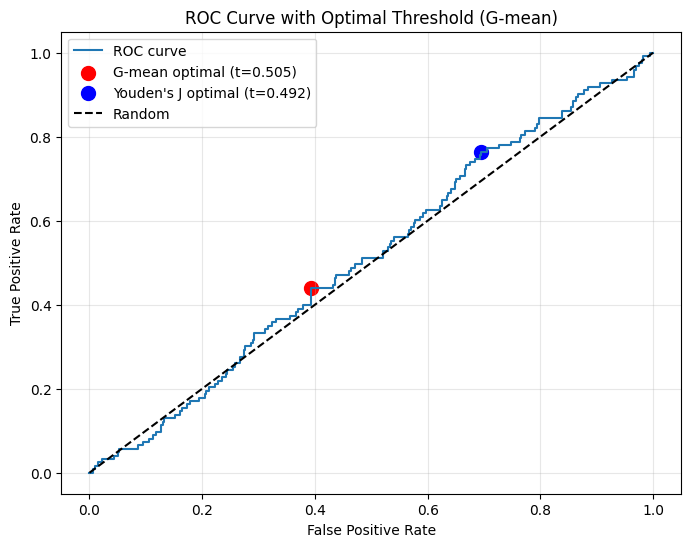

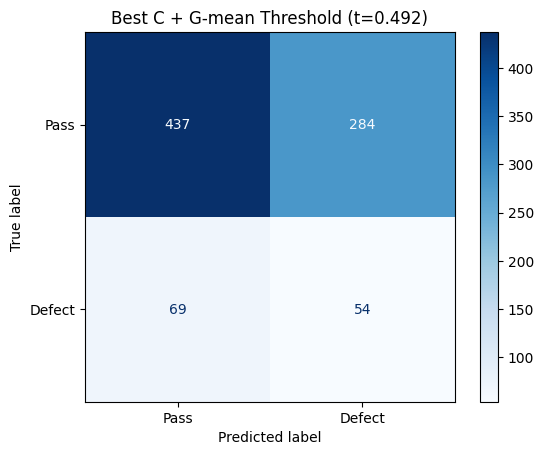

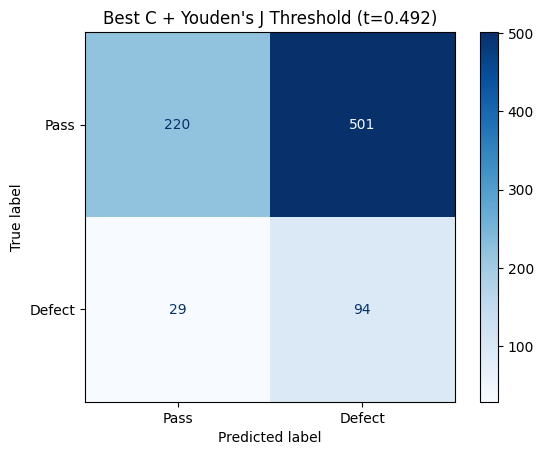

In [46]:
# https://medium.com/data-science/optimal-threshold-for-imbalanced-classification-5884e870c293
#this is the source I referred to

from sklearn.metrics import roc_curve
best_c_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
best_c_model.fit(x_train, y_train)
y_proba = best_c_model.predict_proba(x_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Method 1: G-mean (geometric mean of sensitivity and specificity)
gmean = np.sqrt(tpr * (1 - fpr))
best_idx_gmean = np.argmax(gmean)
best_thresh_gmean = thresholds[best_idx_gmean]

# Method 2: Youden's J statistic (TPR - FPR)
j_scores = tpr - fpr
best_idx_j = np.argmax(j_scores)
best_thresh_j = thresholds[best_idx_j]

print("G-mean optimal threshold:", best_thresh_gmean)
print("Youdens J optimal threshold:", best_thresh_j)

y_pred_gmean = (y_proba >= best_thresh_gmean).astype(int)

print(f"\nG-mean Threshold Results:")
print("MCC:", matthews_corrcoef(y_test, y_pred_gmean))
print("F2:", fbeta_score(y_test, y_pred_gmean, beta=2))
print("Recall:", recall_score(y_test, y_pred_gmean))
print("Precision:", precision_score(y_test, y_pred_gmean, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_gmean))

y_pred_j = (y_proba >= best_thresh_j).astype(int)

print(f"\nYouden's J Threshold Results:")
print("MCC:", matthews_corrcoef(y_test, y_pred_j))
print("F2:", fbeta_score(y_test, y_pred_j, beta=2))
print("Recall:", recall_score(y_test, y_pred_j))
print("Precision:", precision_score(y_test, y_pred_j, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_j))

# Visualize ROC with optimal point
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve')
plt.scatter(fpr[best_idx_gmean], tpr[best_idx_gmean], marker='o', color='red', s=100, label=f'G-mean optimal (t={best_thresh_gmean:.3f})')
plt.scatter(fpr[best_idx_j], tpr[best_idx_j], marker='o', color='blue', s=100, label=f'Youden\'s J optimal (t={best_thresh_j:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold (G-mean)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Confusion matrix
cm_gmean = confusion_matrix(y_test, y_pred_gmean)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gmean, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Best C + G-mean Threshold (t={best_thresh_j:.3f})')
plt.grid(False)
plt.show()

cm_j = confusion_matrix(y_test, y_pred_j)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_j, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Best C + Youden\'s J Threshold (t={best_thresh_j:.3f})')
plt.grid(False)
plt.show()


# 6.2 Undersampling to Remedy Class Imbalance

C  F2  Recall 
-----------------------------------
0.0001 0.0 0.0
0.00026366508987303583 0.0 0.0
0.0006951927961775605 0.0 0.0
0.0018329807108324356 0.0 0.0
0.004832930238571752 0.0 0.0
0.012742749857031334 0.0 0.0
0.03359818286283781 0.0 0.0
0.08858667904100823 0.5268143903381036 0.5262424600052452
0.23357214690901212 0.5156327682463753 0.514080120639916
0.615848211066026 0.5202550373730509 0.5222757671125098
1.623776739188721 0.5216710641096622 0.526308025177026
4.281332398719396 0.5188161458622021 0.5242755048518227
11.288378916846883 0.522218648655784 0.5283405455022292
29.763514416313132 0.5220015845205674 0.5283405455022292
78.47599703514607 0.5220015845205674 0.5283405455022292
206.913808111479 0.5220015845205674 0.5283405455022292
545.5594781168514 0.5220015845205674 0.5283405455022292
1438.44988828766 0.5220015845205674 0.5283405455022292
3792.690190732246 0.5220015845205674 0.5283405455022292
10000.0 0.5220015845205674 0.5283405455022292

Best C (undersampled): 0.088587

Unde

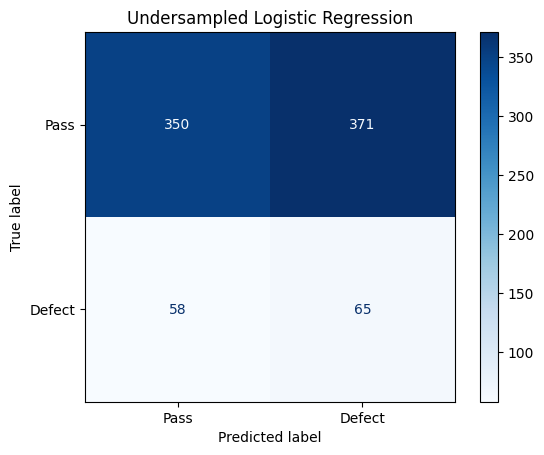

Best threshold: 0.4167002792174901
Best CV score: 0.8335945968464203

Undersampled + Threshold Tuned:
MCC: 0.0
F2: 0.46032934131736525
Recall: 1.0
Precision: 0.1457345971563981
Accuracy: 0.1457345971563981


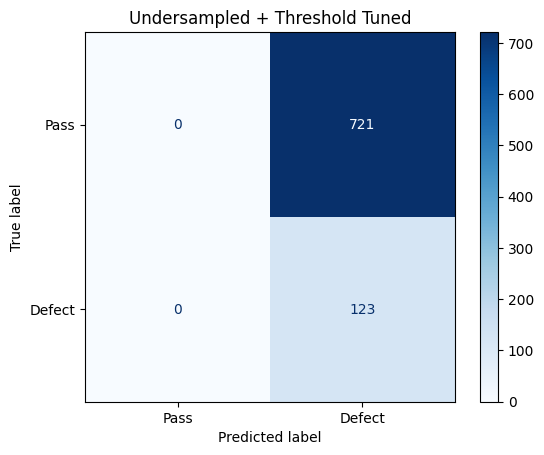

G-mean optimal threshold: 0.4971675137839684
Youdens J optimal threshold: 0.49581463643683577

Optimal Threshold Results:
MCC: 0.06425068164142651
F2: 0.40540540540540543
Recall: 0.6341463414634146
Precision: 0.16595744680851063


Text(0.5, 1.0, 'Undersampled + Threshold Optimized')

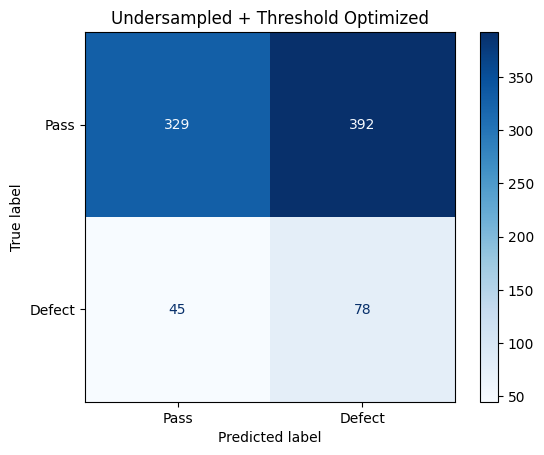

In [49]:
minority_idx = y_train[y_train == 1].index
majority_idx = y_train[y_train == 0].sample(n=len(minority_idx), random_state=RANDOM_STATE).index
balanced_idx = minority_idx.union(majority_idx)

x_train_under = x_train.loc[balanced_idx]
y_train_under = y_train.loc[balanced_idx]
# Re-tune C on undersampled data
C_values = np.logspace(-4, 4, 20)
results_under = []

print(f"C  F2  Recall ")
print("-" * 35)

for C in C_values:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', random_state=RANDOM_STATE)
    
    # CV on undersampled data
    f2_scores = cross_val_score(model, x_train_under, y_train_under, cv=4, scoring=f2_scorer)
    rec_scores = cross_val_score(model, x_train_under, y_train_under, cv=4, scoring='recall')
    
    mean_f2 = np.mean(f2_scores)
    mean_rec = np.mean(rec_scores)
    results_under.append({'C': C, 'F2': mean_f2, 'Recall': mean_rec})
    print(f"{C} {mean_f2} {mean_rec}")

best_C_under = max(results_under, key=lambda x: x['F2'])['C']
print(f"\nBest C (undersampled): {best_C_under:.6f}")
model_under = LogisticRegression(penalty='l1', C=best_C_under, solver='liblinear', random_state=RANDOM_STATE)
model_under.fit(x_train_under, y_train_under)

y_pred_under = model_under.predict(x_test)

print(f"\nUndersampled Log Reg (tuned C):")
print("MCC:", matthews_corrcoef(y_test, y_pred_under))
print("F2:", fbeta_score(y_test, y_pred_under, beta=2))
print("Recall:", recall_score(y_test, y_pred_under))
print("Precision:", precision_score(y_test, y_pred_under, zero_division=0))
cm = confusion_matrix(y_test, y_pred_under)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Undersampled Logistic Regression')
plt.grid(False)
plt.show()
tuned_model_under = TunedThresholdClassifierCV(
    LogisticRegression(penalty='l1', C=best_C_under, solver='liblinear', random_state=RANDOM_STATE),
    scoring=f2_scorer,
    cv=5
)

tuned_model_under.fit(x_train_under, y_train_under)

print("Best threshold:", tuned_model_under.best_threshold_)
print("Best CV score:", tuned_model_under.best_score_)

# Evaluate on original test set
y_pred_tuned_under = tuned_model.predict(x_test)

print(f"\nUndersampled + Threshold Tuned:")
print("MCC:", matthews_corrcoef(y_test, y_pred_tuned_under))
print("F2:", fbeta_score(y_test, y_pred_tuned_under, beta=2))
print("Recall:", recall_score(y_test, y_pred_tuned_under))
print("Precision:", precision_score(y_test, y_pred_tuned_under, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_under))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned_under)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Undersampled + Threshold Tuned')
plt.grid(False)
plt.show()

from sklearn.metrics import roc_curve

# Get probabilities
y_proba = model_under.predict_proba(x_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Method 1: G-mean
gmean = np.sqrt(tpr * (1 - fpr))
best_idx_gmean = np.argmax(gmean)
best_thresh_gmean = thresholds[best_idx_gmean]

# Method 2: Youden's J
j_scores = tpr - fpr
best_idx_j = np.argmax(j_scores)
best_thresh_j = thresholds[best_idx_j]

print("G-mean optimal threshold:", best_thresh_gmean)
print("Youdens J optimal threshold:", best_thresh_j)

# Apply best threshold (they often give same result)
y_pred_optimal = (y_proba >= best_thresh_gmean).astype(int)

print(f"\nOptimal Threshold Results:")
print("MCC:", matthews_corrcoef(y_test, y_pred_optimal))
print("F2:", fbeta_score(y_test, y_pred_optimal, beta=2))
print("Recall:", recall_score(y_test, y_pred_optimal))
print("Precision:", precision_score(y_test, y_pred_optimal, zero_division=0))

cm = confusion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Undersampled + Threshold Optimized')

# 7. Model Comparison

### Matthews Correlation Coefficient (MCC)

MCC is a metric that accounts for all four quadrants of the confusion matrix, making it robust to class imbalance. Unlike accuracy or recall alone, MCC only gives a high score when the model performs well on **both** positive and negative classes.

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Where TP = True Positives, TN = True Negatives, FP = False Positives, FN = False Negatives.

**Interpretation:**
- **+1**: Perfect prediction
- **0**: No better than random guessing
- **-1**: Complete disagreement (predictions are inverted)

MCC is particularly useful here because a model that predicts all samples as "Defect" would achieve high recall but MCC ≈ 0, exposing the lack of true predictive power.


In [50]:
# 1. Vanilla (C=1.0, threshold=0.5)
vanilla_model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
vanilla_model.fit(x_train, y_train)
vanilla_probs = vanilla_model.predict_proba(x_test)[:, 1]
vanilla_preds = (vanilla_probs >= 0.5).astype(int)

# 2. Best C (L1, tuned C, threshold=0.5)
best_c_model = LogisticRegression(penalty='l1', C=best_params['C'], solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
best_c_model.fit(x_train, y_train)
best_c_probs = best_c_model.predict_proba(x_test)[:, 1]
best_c_preds = (best_c_probs >= 0.5).astype(int)

# 3. Best C + Threshold tuning
best_thresh_preds = (best_c_probs >= tuned_model.best_threshold_).astype(int)

def get_metrics(y_true, y_pred):
    return {
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
    }

comparison = pd.DataFrame({
    'Vanilla (C=1.0, t=0.5)': get_metrics(y_test, vanilla_preds),
    'Best C=' + str(round(best_C, 4)) + ', t=0.5': get_metrics(y_test, best_c_preds),
    'Best C + tuned threshold': get_metrics(y_test, best_thresh_preds)
}).T

print(comparison.round(4).to_string())


                             MCC  Recall      F2  Accuracy  Precision
Vanilla (C=1.0, t=0.5)    0.0039  0.4715  0.3273    0.5249     0.1472
Best C=0.0281, t=0.5      0.0091  0.5122  0.3443    0.5024     0.1489
Best C + tuned threshold  0.0000  1.0000  0.4603    0.1457     0.1457


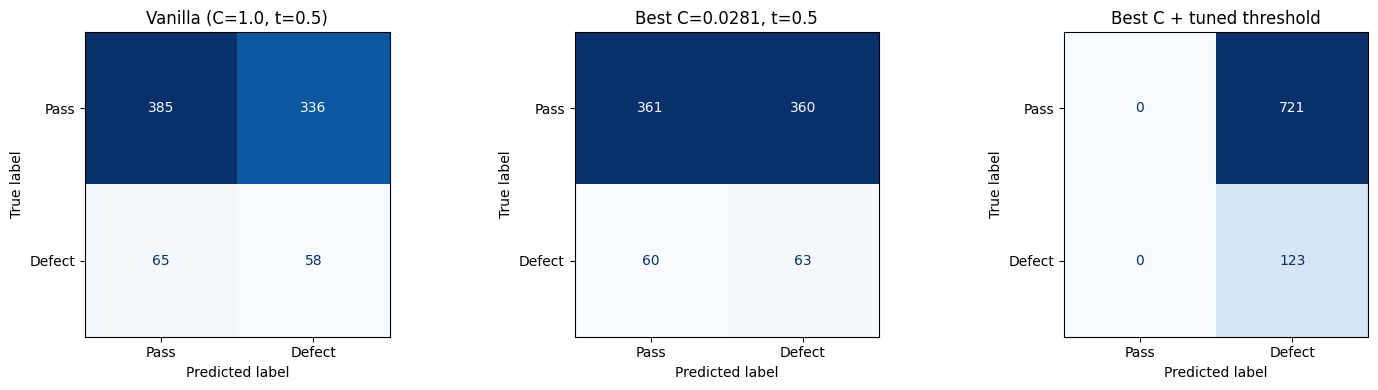

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Vanilla (C=1.0, t=0.5)', 'Best C=' + str(round(best_C, 4)) + ', t=0.5', 'Best C + tuned threshold']
preds_list = [vanilla_preds, best_c_preds, best_thresh_preds]

for ax, preds, title in zip(axes, preds_list, titles):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)
    ax.grid(False)

plt.tight_layout()
plt.show()


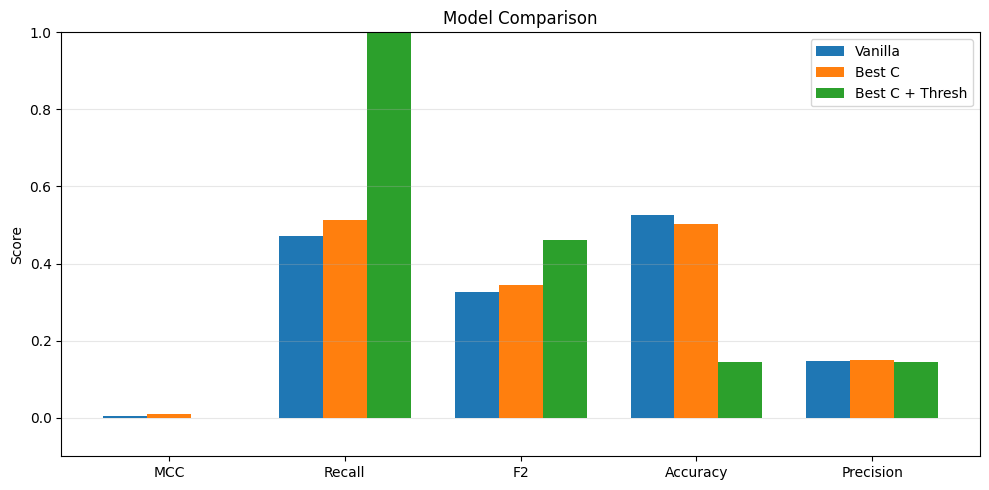

In [52]:
metrics = ['MCC', 'Recall', 'F2', 'Accuracy', 'Precision', ]
x_pos = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width, comparison.iloc[0], width, label='Vanilla')
ax.bar(x_pos, comparison.iloc[1], width, label='Best C')
ax.bar(x_pos + width, comparison.iloc[2], width, label='Best C + Thresh')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.set_ylim(-0.1, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The low MCC score across all models indicates that while the models perform well on metrics like Recall and F2 Score, they struggle with overall balanced classification performance. This suggests that the models may be biased towards one class depending on how the model is tuned, leading to either a high number of false positives or false negatives. Hence, logistic regression, even with tuning, may not be sufficient for this imbalanced classification task, and we will move on to exploring more advanced models to achieve better performance. 

NOW FOR SUPPORT VECTOR MACHINES - 
# 8. SVM Baseline Modeling

Main function of SVMs is to find a hyperplane that separates classes with maximum margin. The hyperparameters we will search over are -
- **C** - Regularization Strength (Inverse)
- **Kernel** - linear, RBF (radial basis function), or polynomial
- **Gamma** - (for RBF/poly): Controls decision boundary flexibility


## 8.1 Vanilla SVM Model Training


In [17]:
svm_linear = SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE)
svm_linear.fit(x_train, y_train)
y_pred_svm = svm_linear.predict(x_test)
print("Vanilla SVM Model Trained!")

print("SVM Linear Baseline:")
print("MCC:", matthews_corrcoef(y_test, y_pred_svm))
print("F2:", fbeta_score(y_test, y_pred_svm, beta=2))
print("Recall:", recall_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Vanilla SVM Model Trained!
SVM Linear Baseline:
MCC: 0.01959182622660593
F2: 0.3540305010893246
Recall: 0.5284552845528455
Precision: 0.15258215962441316
Accuracy: 0.5035545023696683



## 8.2 Cross-Validation Evaluation

In [18]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'f2': f2_scorer}
scores_svm = cross_validate(svm_pipeline, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"Fold  Recall  F2 Score  Precision  F1  Accuracy ")
print("-" * 65)
for i in range(4):
    print(f"{i+1} {scores_svm['test_recall'][i]} {scores_svm['test_f2'][i]} {scores_svm['test_precision'][i]} {scores_svm['test_f1'][i]} {scores_svm['test_accuracy'][i]}")
print("-" * 65)
print("Mean Recall:", np.mean(scores_svm['test_recall']))
print("Mean F2:", np.mean(scores_svm['test_f2']))
print("Mean Precision:", np.mean(scores_svm['test_precision']))
print("Mean Accuracy:", np.mean(scores_svm['test_accuracy']))

Fold  Recall  F2 Score  Precision  F1  Accuracy 
-----------------------------------------------------------------
1 0.4805194805194805 0.33183856502242154 0.14829659318637275 0.22664624808575803 0.5213270142180095
2 0.5064935064935064 0.3427065026362039 0.14942528735632185 0.23076923076923078 0.5071090047393365
3 0.4774193548387097 0.33243486073674755 0.15010141987829614 0.22839506172839505 0.5260663507109005
4 0.4935064935064935 0.3333333333333333 0.1450381679389313 0.22418879056047197 0.5009487666034156
-----------------------------------------------------------------
Mean Recall: 0.48948470883954753
Mean F2: 0.33507831543217653
Mean Precision: 0.1482153670899805
Mean Accuracy: 0.5138627840679155


## 8.3 Hyperparameter Grid Search (Across Kernel, C and gamma for RBF and Polynomial kernel)

### 8.3.1 Linear Kernel

In [19]:
C_values = np.logspace(-2, 2, 5)
gamma_values = np.logspace(-2, 2, 5)
results_svm = []

print(f"Kernel  C  Gamma  F2  Recall ")
print("-" * 55)

# Linear kernel (no gamma)
for C in C_values:
    svm_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='linear', C=C, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    
    f2_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring=f2_scorer)
    rec_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring='recall')
    
    results_svm.append({'Kernel': 'linear', 'C': C, 'Gamma': None, 'F2': np.mean(f2_scores), 'Recall': np.mean(rec_scores)})
    print(f"linear  {C} N/A  {np.mean(f2_scores)} {np.mean(rec_scores)}")



Kernel  C  Gamma  F2  Recall 
-------------------------------------------------------
linear  0.01 N/A  0.3380951932712379 0.4976120653540008
linear  0.1 N/A  0.3331517949510093 0.48624842899036447
linear  1.0 N/A  0.33507831543217653 0.48948470883954753
linear  10.0 N/A  0.3359532060708467 0.49110808546292417
linear  100.0 N/A  0.3358037576688684 0.49110808546292417


### 8.3.3 RBF Kernel

In [20]:
# RBF kernel
for C in C_values:
    for gamma in gamma_values:
        svm_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=RANDOM_STATE))
        ])
        
        f2_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring=f2_scorer)
        rec_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring='recall')
        
        results_svm.append({'Kernel': 'rbf', 'C': C, 'Gamma': gamma, 'F2': np.mean(f2_scores), 'Recall': np.mean(rec_scores)})
        print(f"rbf  {C} {gamma} {np.mean(f2_scores)} {np.mean(rec_scores)}")

results_svm_df = pd.DataFrame(results_svm)

rbf  0.01 0.01 0.34607259930151757 0.75
rbf  0.01 0.1 0.34607259930151757 0.75
rbf  0.01 1.0 0.34607259930151757 0.75
rbf  0.01 10.0 0.34607259930151757 0.75
rbf  0.01 100.0 0.34607259930151757 0.75
rbf  0.1 0.01 0.3480849699424697 0.5414118139924591
rbf  0.1 0.1 0.3167419456679211 0.43110599078341016
rbf  0.1 1.0 0.4613420603793619 1.0
rbf  0.1 10.0 0.4613420603793619 1.0
rbf  0.1 100.0 0.4613420603793619 1.0
rbf  1.0 0.01 0.34256446402741236 0.5137934645999161
rbf  1.0 0.1 0.2901801220924811 0.37598449937159617
rbf  1.0 1.0 0.0 0.0
rbf  1.0 10.0 0.0 0.0
rbf  1.0 100.0 0.0 0.0
rbf  10.0 0.01 0.33477478421861645 0.49595726853791366
rbf  10.0 0.1 0.20339503797380426 0.2268537913699204
rbf  10.0 1.0 0.0 0.0
rbf  10.0 10.0 0.0 0.0
rbf  10.0 100.0 0.0 0.0
rbf  100.0 0.01 0.3351425360416488 0.4781210724759112
rbf  100.0 0.1 0.14719038417627983 0.1523250942605781
rbf  100.0 1.0 0.0 0.0
rbf  100.0 10.0 0.0 0.0
rbf  100.0 100.0 0.0 0.0


Best valid RBF: Kernel         rbf
C              0.1
Gamma         0.01
F2        0.348085
Recall    0.541412
Name: 10, dtype: object
Best Linear: C= 0.01 F2= 0.3380951932712379
Best RBF: C= 0.1 Gamma= 0.01 F2= 0.3480849699424697


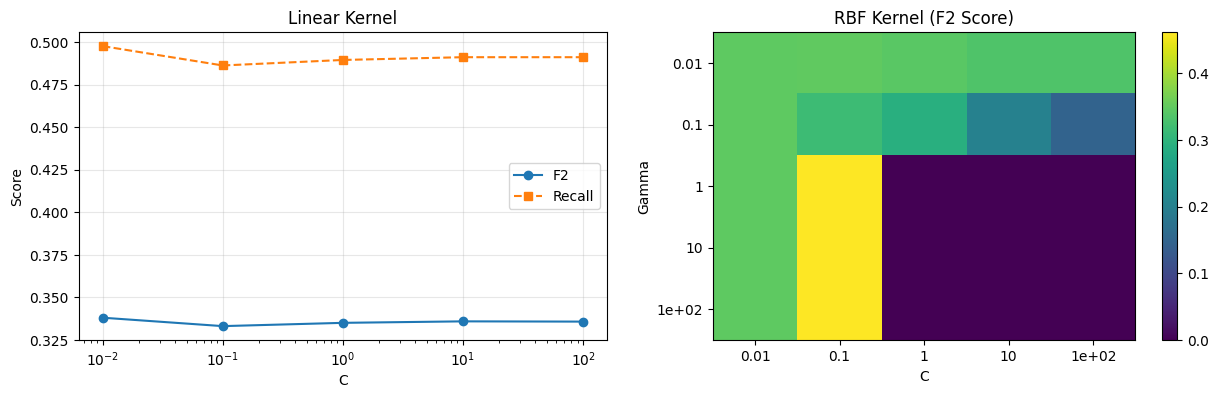

In [21]:
best_linear = results_svm_df[results_svm_df['Kernel'] == 'linear'].loc[results_svm_df[results_svm_df['Kernel'] == 'linear']['F2'].idxmax()]
valid_rbf = results_svm_df[(results_svm_df['Kernel'] == 'rbf') & 
                            (results_svm_df['Recall'] > 0.1) & 
                            (results_svm_df['Recall'] < 0.95)]
best_rbf = valid_rbf.loc[valid_rbf['F2'].idxmax()]
print("Best valid RBF:", best_rbf)

print("Best Linear:", "C=", best_linear["C"], "F2=", best_linear["F2"])
print("Best RBF:", "C=", best_rbf["C"], "Gamma=", best_rbf["Gamma"], "F2=", best_rbf["F2"])
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Linear - just C vs F2
df_linear = results_svm_df[results_svm_df['Kernel'] == 'linear']
axes[0].semilogx(df_linear['C'], df_linear['F2'], 'o-', label='F2')
axes[0].semilogx(df_linear['C'], df_linear['Recall'], 's--', label='Recall')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Score')
axes[0].set_title('Linear Kernel')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RBF - heatmap of C vs Gamma
df_rbf = results_svm_df[results_svm_df['Kernel'] == 'rbf']
pivot_rbf = df_rbf.pivot(index='Gamma', columns='C', values='F2')
im1 = axes[1].imshow(pivot_rbf.values, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(pivot_rbf.columns)))
axes[1].set_xticklabels([f'{c:.2g}' for c in pivot_rbf.columns])
axes[1].set_yticks(range(len(pivot_rbf.index)))
axes[1].set_yticklabels([f'{g:.2g}' for g in pivot_rbf.index])
axes[1].set_xlabel('C')
axes[1].set_ylabel('Gamma')
axes[1].set_title('RBF Kernel (F2 Score)')
plt.colorbar(im1, ax=axes[1])

           MCC  Recall      F2  Accuracy  Precision
Linear  0.0312  0.5366  0.3614    0.5118     0.1568
RBF    -0.0046  0.5122  0.3391    0.4858     0.1442


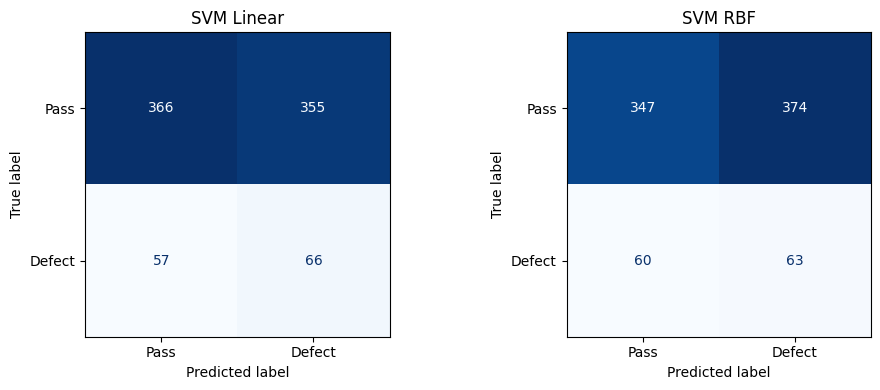

In [22]:
svm_best_linear = SVC(kernel='linear', C=best_linear['C'], class_weight='balanced', random_state=RANDOM_STATE)
svm_best_linear.fit(x_train, y_train)
pred_linear = svm_best_linear.predict(x_test)

# Best RBF
svm_best_rbf = SVC(kernel='rbf', C=best_rbf['C'], gamma=best_rbf['Gamma'], class_weight='balanced', random_state=RANDOM_STATE)
svm_best_rbf.fit(x_train, y_train)
pred_rbf = svm_best_rbf.predict(x_test)

# Metrics comparison
def get_metrics_svm(y_true, y_pred):
    return {
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
    }

comparison_svm = pd.DataFrame({
    'Linear': get_metrics_svm(y_test, pred_linear),
    'RBF': get_metrics_svm(y_test, pred_rbf)
}).T

print(comparison_svm.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred, title in zip(axes, [pred_linear, pred_rbf], ['Linear', 'RBF']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(f'SVM {title}')
    ax.grid(False)

plt.tight_layout()
plt.show()

Since SVM with Linear Kernel performed better - 

Undersampled: {np.int64(0): np.int64(494), np.int64(1): np.int64(494)}
C  F2  Recall  MCC 
---------------------------------------------
0.001 0.41610284167794315 0.5 0.0
0.0026826957952797246 0.4878122437212466 0.5543371361132966 0.01910033700312366
0.0071968567300115215 0.5421746479906795 0.5505507474429583 0.030394362583669936
0.019306977288832496 0.5320340726386177 0.5384539732494098 0.01600690925807019
0.0517947467923121 0.5242414600601492 0.5283733280881195 0.01819989489144365
0.13894954943731375 0.5337494543254265 0.5404537109887227 0.020106868966040213
0.3727593720314938 0.5336230793926431 0.540470102281668 0.018131031905648333
1.0 0.5318691251892549 0.5384539732494099 0.01608142745822052
2.6826957952797246 0.530106201651547 0.5364378442171518 0.01405800820265424
7.196856730011514 0.5354610324464893 0.5425026226068712 0.02013661417481957
19.306977288832496 0.5387384934077556 0.546584054550223 0.02012456467930398
51.794746792312125 0.5387384934077556 0.546584054550223 0.02012456

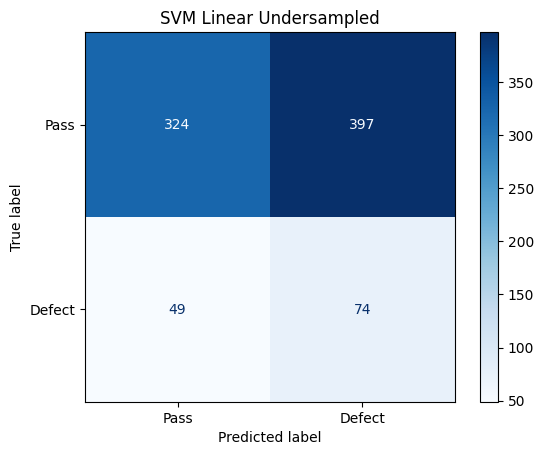

In [23]:
minority_idx = y_train[y_train == 1].index
majority_idx = y_train[y_train == 0].sample(n=len(minority_idx), random_state=RANDOM_STATE).index
balanced_idx = minority_idx.union(majority_idx)

x_train_under = x_train.loc[balanced_idx]
y_train_under = y_train.loc[balanced_idx]

print(f"Undersampled: {dict(zip(*np.unique(y_train_under, return_counts=True)))}")
C_values = np.logspace(-3, 3, 15)
results_svm_under = []

print(f"C  F2  Recall  MCC ")
print("-" * 45)

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=RANDOM_STATE)
    
    f2_scores = cross_val_score(svm, x_train_under, y_train_under, cv=4, scoring=f2_scorer)
    rec_scores = cross_val_score(svm, x_train_under, y_train_under, cv=4, scoring='recall')
    mcc_scorer = make_scorer(matthews_corrcoef)
    mcc_scores = cross_val_score(svm, x_train_under, y_train_under, cv=4, scoring=mcc_scorer)
    
    results_svm_under.append({
        'C': C, 
        'F2': np.mean(f2_scores), 
        'Recall': np.mean(rec_scores),
        'MCC': np.mean(mcc_scores)
    })
    print(f"{C} {np.mean(f2_scores)} {np.mean(rec_scores)} {np.mean(mcc_scores)}")

results_svm_under_df = pd.DataFrame(results_svm_under)
best_C_svm = results_svm_under_df.loc[results_svm_under_df['MCC'].idxmax(), 'C']
print("Best C (by MCC):", best_C_svm)
svm_best = SVC(kernel='linear', C=20, random_state=RANDOM_STATE)
svm_best.fit(x_train_under, y_train_under)
y_pred_svm_best = svm_best.predict(x_test)

print("SVM Linear (Undersampled):")
print("MCC:", matthews_corrcoef(y_test, y_pred_svm_best))
print("F2:", fbeta_score(y_test, y_pred_svm_best, beta=2))
print("Recall:", recall_score(y_test, y_pred_svm_best))
print("Precision:", precision_score(y_test, y_pred_svm_best, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_svm_best))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('SVM Linear Undersampled')
plt.grid(False)
plt.show()

## 8.4 Polynomial Kernel Tests
These take a long time so we kept our C and gamma search grids smaller (based on results we saw from previous models)

In [24]:
print(f"Degree  C  Gamma  MCC  F2  Recall ")
print("-" * 60)

poly_results = []
for degree in [2, 3]:
    for C in [0.01, 0.1, 1.0]:
        for gamma in [0.01, 0.1, 1.0]:
            svm_poly = SVC(kernel='poly', degree=degree, C=C, gamma=gamma, class_weight='balanced', random_state=RANDOM_STATE)
            svm_poly.fit(x_train, y_train)
            pred = svm_poly.predict(x_test)
            mcc = matthews_corrcoef(y_test, pred)
            f2 = fbeta_score(y_test, pred, beta=2)
            rec = recall_score(y_test, pred)
            poly_results.append({'Degree': degree, 'C': C, 'Gamma': gamma, 'MCC': mcc, 'F2': f2, 'Recall': rec})
            print(f"{degree} {C} {gamma} {mcc} {f2} {rec}")

poly_df = pd.DataFrame(poly_results)
best_poly = poly_df.loc[poly_df['MCC'].idxmax()]
print("Best Poly:", "degree=", int(best_poly["Degree"]), "C=", best_poly["C"], "gamma=", best_poly["Gamma"])


Degree  C  Gamma  MCC  F2  Recall 
------------------------------------------------------------
2 0.01 0.01 0.0 0.0 0.0
2 0.01 0.1 -0.014225617791118441 0.0 0.0
2 0.01 1.0 -0.015948101069455673 0.32608695652173914 0.4878048780487805
2 0.1 0.01 0.0 0.0 0.0
2 0.1 0.1 -0.025083067955499538 0.30726256983240224 0.44715447154471544
2 0.1 1.0 -0.02016468154468395 0.3304904051172708 0.5040650406504065
2 1.0 0.01 -0.014225617791118441 0.0 0.0
2 1.0 0.1 -0.015948101069455673 0.32608695652173914 0.4878048780487805
2 1.0 1.0 -0.00980347158967828 0.34282700421940926 0.5284552845528455
3 0.01 0.01 0.0 0.0 0.0
3 0.01 0.1 -0.020130004660759433 0.0 0.0
3 0.01 1.0 0.028004296663939148 0.330188679245283 0.45528455284552843
3 0.1 0.01 0.0 0.0 0.0
3 0.1 0.1 -0.027333876353898192 0.2217741935483871 0.2682926829268293
3 0.1 1.0 0.03503917895356828 0.3329369797859691 0.45528455284552843
3 1.0 0.01 0.0 0.0 0.0
3 1.0 0.1 0.027667369393635448 0.32004830917874394 0.43089430894308944
3 1.0 1.0 0.02520791664012666 

In [25]:
svm_poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='poly', degree=int(best_poly['Degree']), C=best_poly['C'], gamma=best_poly['Gamma'], class_weight='balanced', random_state=RANDOM_STATE))
])

scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'f2': f2_scorer}
scores_poly = cross_validate(svm_poly_pipe, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"Best Poly SVM Cross-Validation Results:")
print(f"Fold  Recall  F2  Precision  Accuracy ")
print("-" * 50)
for i in range(4):
    print(f"{i+1} {scores_poly['test_recall'][i]} {scores_poly['test_f2'][i]} {scores_poly['test_precision'][i]} {scores_poly['test_accuracy'][i]}")
print("-" * 50)
print(f"Mean:  {np.mean(scores_poly['test_recall'])} {np.mean(scores_poly['test_f2'])} {np.mean(scores_poly['test_precision'])} {np.mean(scores_poly['test_accuracy'])}")


svm_best_poly = SVC(kernel='poly', degree=int(best_poly['Degree']), C=best_poly['C'], gamma=best_poly['Gamma'], class_weight='balanced', random_state=RANDOM_STATE)
svm_best_poly.fit(x_train, y_train)
pred_poly = svm_best_poly.predict(x_test)


Best Poly SVM Cross-Validation Results:
Fold  Recall  F2  Precision  Accuracy 
--------------------------------------------------
1 0.35714285714285715 0.2644230769230769 0.12971698113207547 0.5563981042654028
2 0.3961038961038961 0.2899239543726236 0.13990825688073394 0.5563981042654028
3 0.4064516129032258 0.31003937007874016 0.1590909090909091 0.5971563981042654
4 0.3961038961038961 0.2850467289719626 0.1343612334801762 0.538899430740038
--------------------------------------------------
Mean:  0.3889505655634688 0.2873582825866008 0.14076934514597367 0.5622130093437773


## 8.5 SVM Model Comparison

SVM Model Comparison:
                    MCC  Recall      F2  Accuracy  Precision
Vanilla Linear   0.0196  0.5285  0.3540    0.5036     0.1526
Best Linear      0.0312  0.5366  0.3614    0.5118     0.1568
Best RBF        -0.0046  0.5122  0.3391    0.4858     0.1442
Best Poly (d=3)  0.0350  0.4553  0.3329    0.5735     0.1605


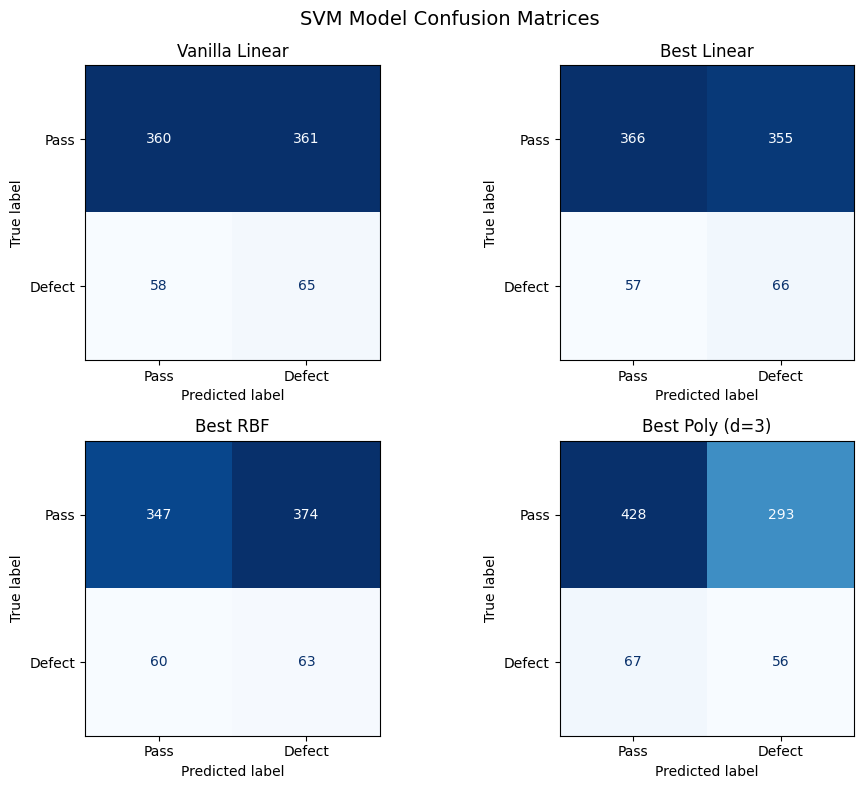

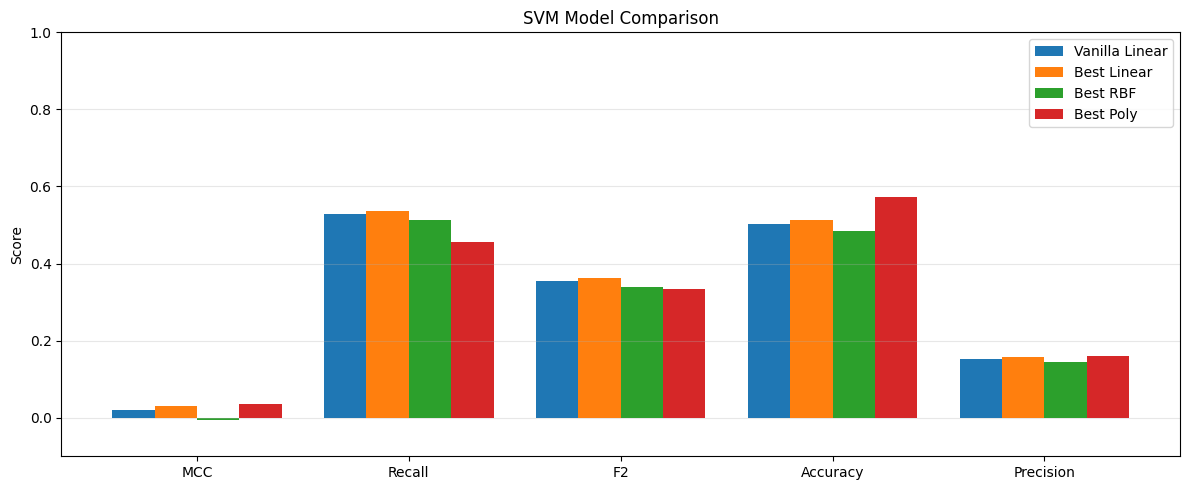

In [26]:
svm_final_comparison = pd.DataFrame({
    'Vanilla Linear': get_metrics_svm(y_test, y_pred_svm),
    "Best Linear": get_metrics_svm(y_test, pred_linear),
    f'Best RBF': get_metrics_svm(y_test, pred_rbf),
    f'Best Poly (d={int(best_poly["Degree"])})': get_metrics_svm(y_test, pred_poly)
}).T

print("SVM Model Comparison:")
print(svm_final_comparison.round(4).to_string())
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

predictions = [y_pred_svm, pred_linear, pred_rbf, pred_poly]
titles = ['Vanilla Linear', "Best Linear", 'Best RBF', f'Best Poly (d={int(best_poly["Degree"])})']

for ax, pred, title in zip(axes, predictions, titles):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)
    ax.grid(False)

plt.suptitle('SVM Model Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()
metrics = ['MCC', 'Recall', 'F2', 'Accuracy', 'Precision']
x_pos = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 1.5*width, svm_final_comparison.iloc[0], width, label='Vanilla Linear')
ax.bar(x_pos - 0.5*width, svm_final_comparison.iloc[1], width, label='Best Linear')
ax.bar(x_pos + 0.5*width, svm_final_comparison.iloc[2], width, label='Best RBF')
ax.bar(x_pos + 1.5*width, svm_final_comparison.iloc[3], width, label='Best Poly')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('SVM Model Comparison')
ax.legend()
ax.set_ylim(-0.1, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 9 Adaboost 

## 9.1 Baseline Modeling

### 9.1.1 Vanilla Adaboost Model Training

Vanilla AdaBoost:
MCC: 0.0
F2: 0.0
Recall: 0.0
Precision: 0.0
Accuracy: 0.8542654028436019


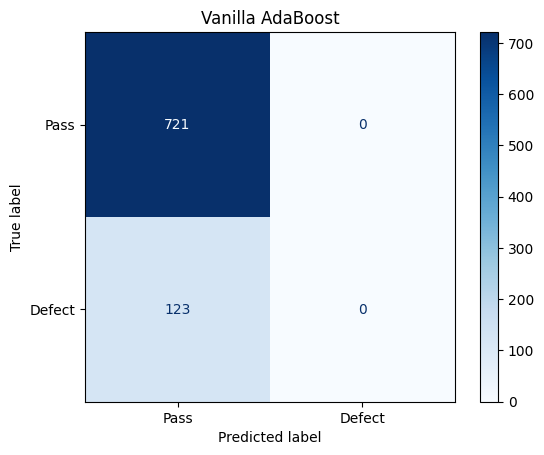

In [27]:
ada_vanilla = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=10,
    learning_rate=1,
    random_state=RANDOM_STATE
)
ada_vanilla.fit(x_train, y_train)
y_pred_ada = ada_vanilla.predict(x_test)

print("Vanilla AdaBoost:")
print("MCC:", matthews_corrcoef(y_test, y_pred_ada))
print("F2:", fbeta_score(y_test, y_pred_ada, beta=2))
print("Recall:", recall_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

cm = confusion_matrix(y_test, y_pred_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Vanilla AdaBoost')
plt.grid(False)
plt.show()

## 9.2 Handling Class Imbalance via Undersampling

The dataset is imbalanced. Instead of oversampling or SMOTE, we split the majority class into multiple chunks and train one AdaBoost model per chunk, each with all minority samples included. This creates several balanced models, whose predictions we later average.

In [28]:
train_df = pd.concat([x_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
majority_df = train_df[train_df["Defect"] == 0].reset_index(drop=True)
minority_df = train_df[train_df["Defect"] == 1].reset_index(drop=True)
print("Majority size:", len(majority_df))
print("Minority size:", len(minority_df))
n_minority = len(minority_df)
n_majority = len(majority_df)
n_chunks = int(np.ceil(n_majority / n_minority))
majority_chunks = np.array_split(majority_df, n_chunks)
for i, ch in enumerate(majority_chunks):
    print(f"Chunk {i+1} size = {len(ch)}")

Majority size: 2881
Minority size: 494
Chunk 1 size = 481
Chunk 2 size = 480
Chunk 3 size = 480
Chunk 4 size = 480
Chunk 5 size = 480
Chunk 6 size = 480


/Users/aryankulkarni/Documents/UC Berkeley Coursework/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## 9.3 AdaBoost Hyperparameter Search

For each learning rate and number of estimators, we train one AdaBoost model per majority chunk (balanced datasets), average their predicted probabilities, and evaluate using MCC, Recall, and F2-score.

Learning Rate n_estimators MCC F2 Recall
------------------------------------------------------------
0.25 25 -0.0264 0.4465 0.9431
0.25 50 -0.0336 0.4096 0.7886
0.25 100 0.0043 0.4203 0.7886
0.25 200 0.0081 0.4122 0.748
0.5 25 -0.034 0.3993 0.748
0.5 50 0.021 0.4109 0.7236
0.5 100 0.0262 0.4108 0.7154
0.5 200 0.0088 0.3962 0.6829
0.75 25 0.0112 0.3861 0.6423
0.75 50 0.0161 0.3924 0.6585
0.75 100 0.0234 0.3838 0.6179
0.75 200 -0.0069 0.3625 0.5854
1.0 25 0.0035 0.3762 0.6179
1.0 50 0.0153 0.3854 0.6341
1.0 100 -0.0203 0.3333 0.5122
1.0 200 -0.009 0.3459 0.5366


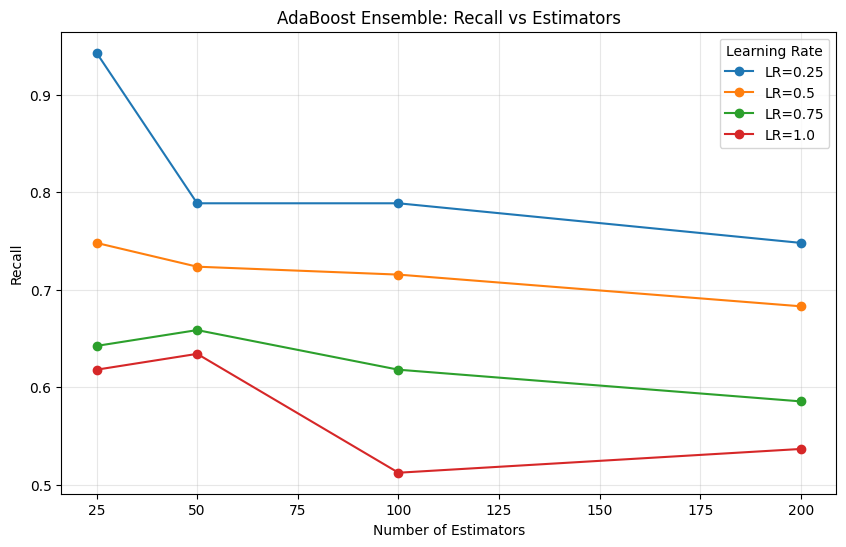

In [30]:
learning_rates = [0.25, 0.5, 0.75, 1.0]
n_estimators_list = [25, 50, 100, 200]

results_ada = []

print("Learning Rate", "n_estimators", "MCC", "F2", "Recall")
print("-" * 60)

for lr in learning_rates:
    for n_est in n_estimators_list:
        probas_all_models = []

        # Train one model per chunk
        for i, chunk in enumerate(majority_chunks):
            balanced_df = pd.concat([chunk, minority_df], axis=0)
            balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE+i).reset_index(drop=True)

            Xb = balanced_df.drop(columns=["Defect"])
            yb = balanced_df["Defect"]

            ada = AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=1),
                n_estimators=n_est,
                learning_rate=lr,
                random_state=RANDOM_STATE
            )

            ada.fit(Xb, yb)
            probas_all_models.append(ada.predict_proba(x_test)[:, 1])

        # Average probabilities across model ensemble
        avg_probas = np.mean(probas_all_models, axis=0)
        y_pred = (avg_probas >= 0.5).astype(int)

        mcc = matthews_corrcoef(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)

        results_ada.append({'LR': lr, 'n_est': n_est, 'MCC': mcc, 'F2': f2, 'Recall': recall})
        print(lr, n_est, round(mcc, 4), round(f2, 4), round(recall, 4))

results_ada_df = pd.DataFrame(results_ada)

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    df_lr = results_ada_df[results_ada_df['LR'] == lr]
    plt.plot(df_lr['n_est'], df_lr['Recall'], marker='o', label=f'LR={lr}')

plt.xlabel('Number of Estimators')
plt.ylabel('Recall')
plt.title('AdaBoost Ensemble: Recall vs Estimators')
plt.grid(alpha=0.3)
plt.legend(title='Learning Rate')
plt.show()

### Best Model based on Hyperparameter Tuning

Best AdaBoost Configuration (by MCC):
Learning Rate: 0.5
n_estimators: 100

Best AdaBoost Results:
MCC: 0.0262
F2: 0.4108
Recall: 0.7154
Precision: 0.1520
Accuracy: 0.3768


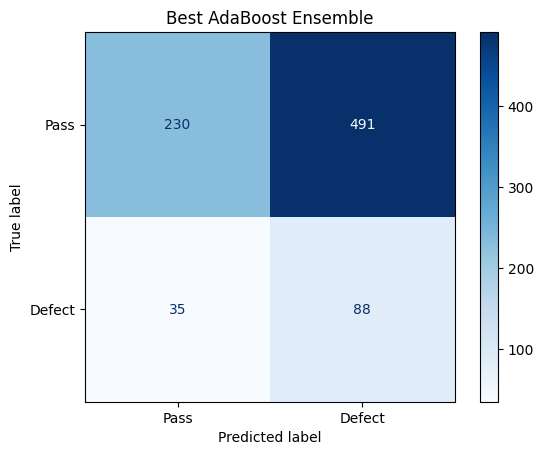

In [53]:
best_ada = results_ada_df.loc[results_ada_df['MCC'].idxmax()]
print("Best AdaBoost Configuration (by MCC):")
print("Learning Rate:", best_ada['LR'])
print("n_estimators:", int(best_ada['n_est']))

# Rebuild best model ensemble
probas_all_models = []
for i, chunk in enumerate(majority_chunks):
    balanced_df = pd.concat([chunk, minority_df], axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE+i).reset_index(drop=True)

    Xb = balanced_df.drop(columns=["Defect"])
    yb = balanced_df["Defect"]

    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=int(best_ada['n_est']),
        learning_rate=best_ada['LR'],
        random_state=RANDOM_STATE
    )

    ada.fit(Xb, yb)
    probas_all_models.append(ada.predict_proba(x_test)[:, 1])

avg_probas = np.mean(probas_all_models, axis=0)
y_pred_best_ada = (avg_probas >= 0.5).astype(int)

print("\nBest AdaBoost Results:")
print("MCC:", f"{matthews_corrcoef(y_test, y_pred_best_ada):.4f}")
print("F2:", f"{fbeta_score(y_test, y_pred_best_ada, beta=2):.4f}")
print("Recall:", f"{recall_score(y_test, y_pred_best_ada):.4f}")
print("Precision:", f"{precision_score(y_test, y_pred_best_ada, zero_division=0):.4f}")
print("Accuracy:", f"{accuracy_score(y_test, y_pred_best_ada):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Best AdaBoost Ensemble')
plt.grid(False)
plt.show()

## 9.4 AdaBoost Model Comparison

AdaBoost Model Comparison:
                     MCC  Recall      F2  Accuracy  Precision
Vanilla AdaBoost  0.0000  0.0000  0.0000    0.8543      0.000
Best Ensemble     0.0262  0.7154  0.4108    0.3768      0.152


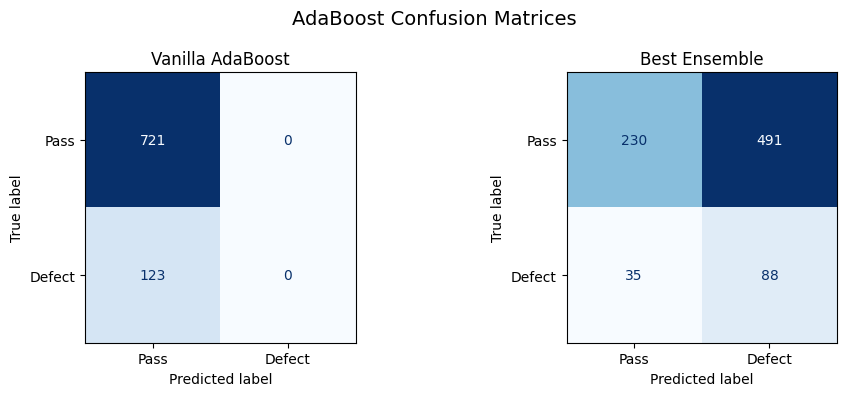

In [54]:
def get_metrics_ada(y_true, y_pred):
    return {
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0)
    }

ada_comparison = pd.DataFrame({
    'Vanilla AdaBoost': get_metrics_ada(y_test, y_pred_ada),
    'Best Ensemble': get_metrics_ada(y_test, y_pred_best_ada)
}).T

print("AdaBoost Model Comparison:")
print(ada_comparison.round(4).to_string())

# Side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_vanilla = confusion_matrix(y_test, y_pred_ada)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_vanilla, display_labels=['Pass', 'Defect'])
disp1.plot(cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title('Vanilla AdaBoost')
axes[0].grid(False)

cm_best = confusion_matrix(y_test, y_pred_best_ada)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Pass', 'Defect'])
disp2.plot(cmap='Blues', values_format='d', ax=axes[1], colorbar=False)
axes[1].set_title('Best Ensemble')
axes[1].grid(False)

plt.suptitle('AdaBoost Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()